## Naive Bayes

In [1]:
import pandas as pd
naive = pd.read_csv("Hr_comma_sep.csv")

In [2]:
naive

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [3]:
naive.head(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [4]:
x=naive.drop("left",axis=1)
y=naive["left"]


In [5]:
x

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,0,sales,low
1,0.80,0.86,5,262,6,0,0,sales,medium
2,0.11,0.88,7,272,4,0,0,sales,medium
3,0.72,0.87,5,223,5,0,0,sales,low
4,0.37,0.52,2,159,3,0,0,sales,low
...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,0,support,low
14995,0.37,0.48,2,160,3,0,0,support,low
14996,0.37,0.53,2,143,3,0,0,support,low
14997,0.11,0.96,6,280,4,0,0,support,low


In [6]:
y

0        1
1        1
2        1
3        1
4        1
        ..
14994    1
14995    1
14996    1
14997    1
14998    1
Name: left, Length: 14999, dtype: int64

In [7]:
x.isnull()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,sales,salary
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
14994,False,False,False,False,False,False,False,False,False
14995,False,False,False,False,False,False,False,False,False
14996,False,False,False,False,False,False,False,False,False
14997,False,False,False,False,False,False,False,False,False


In [9]:
x.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

In [10]:
y.isnull().sum()

np.int64(0)

In [11]:
y.isnull()

0        False
1        False
2        False
3        False
4        False
         ...  
14994    False
14995    False
14996    False
14997    False
14998    False
Name: left, Length: 14999, dtype: bool

In [14]:
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.metrics import r2_score 
from sklearn.model_selection import train_test_split

In [15]:
from sklearn.model_selection import train_test_split

In [17]:
x_train, x_test, y_train  , y_test =train_test_split(x,y, random_state=24 , test_size=0.3, stratify=y)

In [27]:
from sklearn.preprocessing import OneHotEncoder

In [28]:
from sklearn.naive_bayes import GaussianNB

In [31]:
ohe = OneHotEncoder(sparse_output=False, 
      handle_unknown='ignore').set_output(transform='pandas')
      
nb = GaussianNB()

In [34]:
from sklearn.pipeline import Pipeline


In [35]:
pipe = Pipeline([('OHE', ohe),('NB',nb)])
pipe.fit(x_train, y_train)

,steps,"[('OHE', ...), ('NB', ...)]"
,transform_input,None
,memory,None
,verbose,False
,categories,'auto'
,drop,None
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None


In [38]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [39]:
y_pred = pipe.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.70      0.82      3429
           1       0.50      0.97      0.66      1071

    accuracy                           0.76      4500
   macro avg       0.74      0.83      0.74      4500
weighted avg       0.87      0.76      0.78      4500



In [42]:
from sklearn.metrics import roc_auc_score

In [43]:
y_pred_prob = pipe.predict_proba(x_test)[:,1]
print(roc_auc_score(y_test, y_pred_prob))

0.839040136322829


In [44]:

# Evaluation
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[2390 1039]
 [  29 1042]]

Accuracy: 0.7626666666666667

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.70      0.82      3429
           1       0.50      0.97      0.66      1071

    accuracy                           0.76      4500
   macro avg       0.74      0.83      0.74      4500
weighted avg       0.87      0.76      0.78      4500



In [46]:
import matplotlib.pyplot as plt

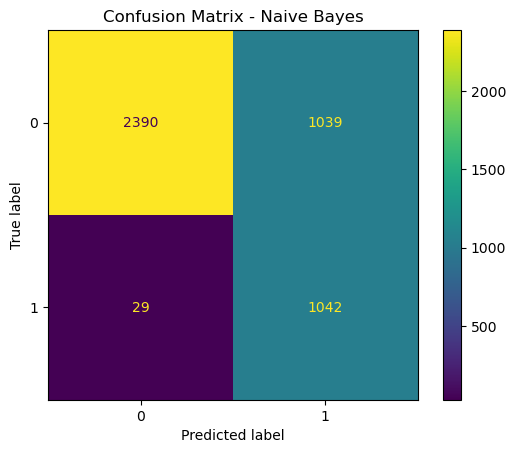

In [47]:

# Confusion matrix display 
ConfusionMatrixDisplay.from_predictions(y_test, y_pred) 
plt.title("Confusion Matrix - Naive Bayes") 
plt.show()

In [48]:
naive.head(67)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
62,0.10,0.95,6,244,5,0,1,0,IT,medium
63,0.36,0.56,2,132,3,0,1,0,IT,medium
64,0.11,0.94,6,286,4,0,1,0,IT,medium
65,0.81,0.70,6,161,4,0,1,0,IT,medium
